# Clustering K-Means
## Dataset: Hotel Bookings

**K-Means** divide los datos en `k` grupos minimizando la distancia de cada punto
a su centroide (centro del grupo). A diferencia del clustering jerárquico, K-Means
requiere especificar el número de clusters de antemano, pero es mucho más rápido
en datasets grandes.

### Flujo de trabajo
```
mf.KMeans(path, num)        # 1. Cargar datos
    ↓ métodos EDA heredados  # 2. Limpiar y preparar
km.ajustar()                # 3. Ajustar el modelo
km.plot_*()                 # 4. Visualizar resultados
```

## 1. Importación de librerías

In [1]:
import sys
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
import pckEDA as mf

%matplotlib inline
print('Clase KMeans disponible:', mf.KMeans)

Clase KMeans disponible: <class 'pckEDA.no_supervisado.kmeans.KMeans'>


## 2. Carga de datos

In [2]:
km = mf.KMeans('../datasets/hotel_bookings.csv', 1, n_clusters=4)

km.mostrarTamaño()
km.muestraTiposDeDatos()

Tamaño del DataFrame: (408, 20)
hotel                           object
is_canceled                      int64
lead_time                        int64
arrival_date_month              object
stays_in_weekend_nights          int64
                                ...   
customer_type                   object
adr                            float64
required_car_parking_spaces      int64
total_of_special_requests        int64
reservation_status              object
Length: 20, dtype: object


## 3. Preprocesamiento con métodos heredados del EDA

In [3]:
km.codificarCategorica('hotel')
km.codificarCategorica('arrival_date_month')
km.codificarCategorica('assigned_room_type')
km.codificarCategorica('deposit_type', mapeo={'No Deposit': 0, 'Non Refund': 1, 'Refundable': 2})
km.codificarCategorica('customer_type')
km.codificarCategorica('reservation_status')
km.eliminarDuplicados()
km.eliminarNulos()
km.analisisNumerico()
print(f'Columnas para el modelo: {list(km.df.columns)}')

Columna 'hotel' codificada con el mapeo:
  City Hotel → 0
  Resort Hotel → 1
Columna 'arrival_date_month' codificada con el mapeo:
  April → 0
  August → 1
  February → 2
  January → 3
  July → 4
  June → 5
  March → 6
  May → 7
Columna 'assigned_room_type' codificada con el mapeo:
  A → 0
  B → 1
  C → 2
  D → 3
  E → 4
  F → 5
  G → 6
  H → 7
  I → 8
  K → 9
Columna 'deposit_type' codificada con el mapeo:
  No Deposit → 0
  Non Refund → 1
  Refundable → 2
Columna 'customer_type' codificada con el mapeo:
  Contract → 0
  Group → 1
  Transient → 2
  Transient-Party → 3
Columna 'reservation_status' codificada con el mapeo:
  Canceled → 0
  Check-Out → 1
  No-Show → 2
Se eliminaron 13 filas duplicadas. Total actual: 395 filas.
Valores nulos antes: 0 en 395 filas.
hotel                          0
is_canceled                    0
lead_time                      0
arrival_date_month             0
stays_in_weekend_nights        0
                              ..
customer_type                 

## 4. Selección del número óptimo de clusters

Antes de ajustar el modelo final, usamos el **método del codo** y el
**coeficiente de Silhouette** para elegir el mejor valor de `k`.

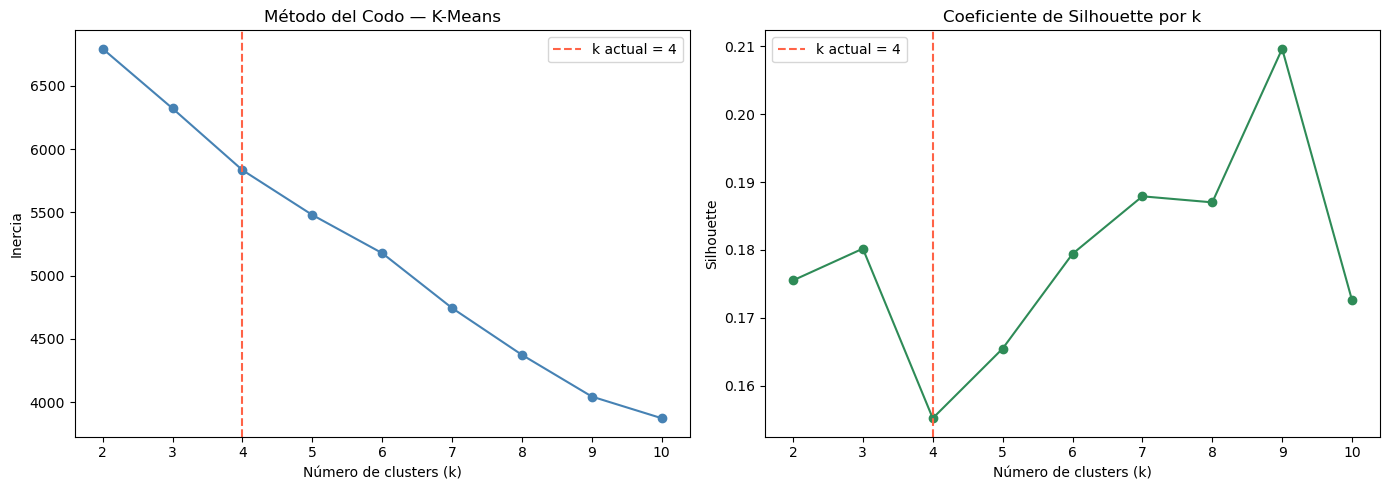

In [4]:
# Necesitamos los datos escalados antes de graficar — ajustamos primero con k=4
km.ajustar()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(axes[0])
km.plot_codo(max_clusters=10)

plt.sca(axes[1])
km.plot_silhouette(max_clusters=10)

plt.tight_layout()
plt.show()

## 5. Métricas del modelo

In [5]:
import pandas as pd

print(f'Número de clusters : {km.n_clusters}')
print(f'Inercia            : {km.inercia:.2f}')
print(f'Silhouette         : {km.silhouette:.4f}')
print()
print('Distribución de observaciones por cluster:')
print(pd.Series(km.etiquetas).value_counts().sort_index())

Número de clusters : 4
Inercia            : 5834.15
Silhouette         : 0.1552

Distribución de observaciones por cluster:
0    180
1    176
2     34
3      5
Name: count, dtype: int64


> **Inercia:** suma de distancias cuadradas al centroide — menor es mejor.  
> **Silhouette ≥ 0.50** → clusters bien separados. **≥ 0.70** → excelente separación.

## 6. Visualizaciones

### 6.1 Mapa de calor — Perfil de clusters

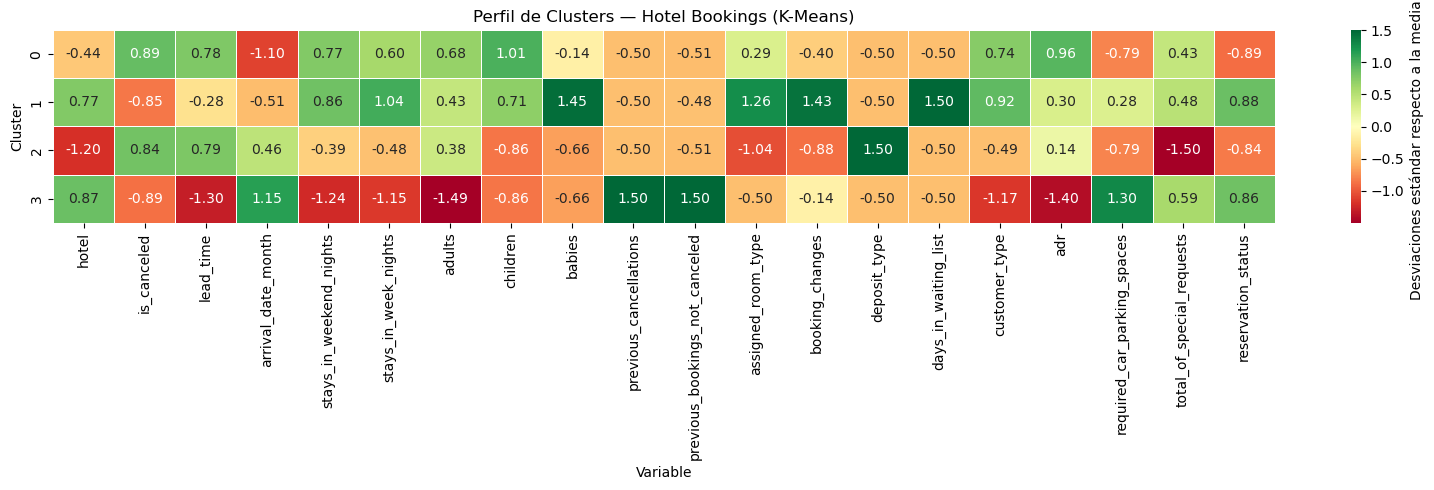

In [6]:
plt.figure(figsize=(16, 5))
km.plot_mapa_calor(titulo='Perfil de Clusters — Hotel Bookings (K-Means)')
plt.tight_layout()
plt.show()

### 6.2 Distribución de observaciones por cluster

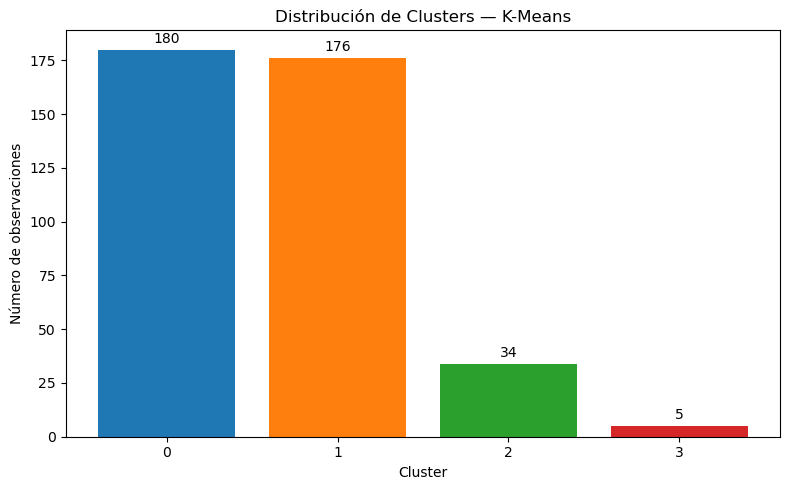

In [7]:
plt.figure(figsize=(8, 5))
km.plot_distribucion()
plt.tight_layout()
plt.show()

### 6.3 Diagramas de dispersión por cluster

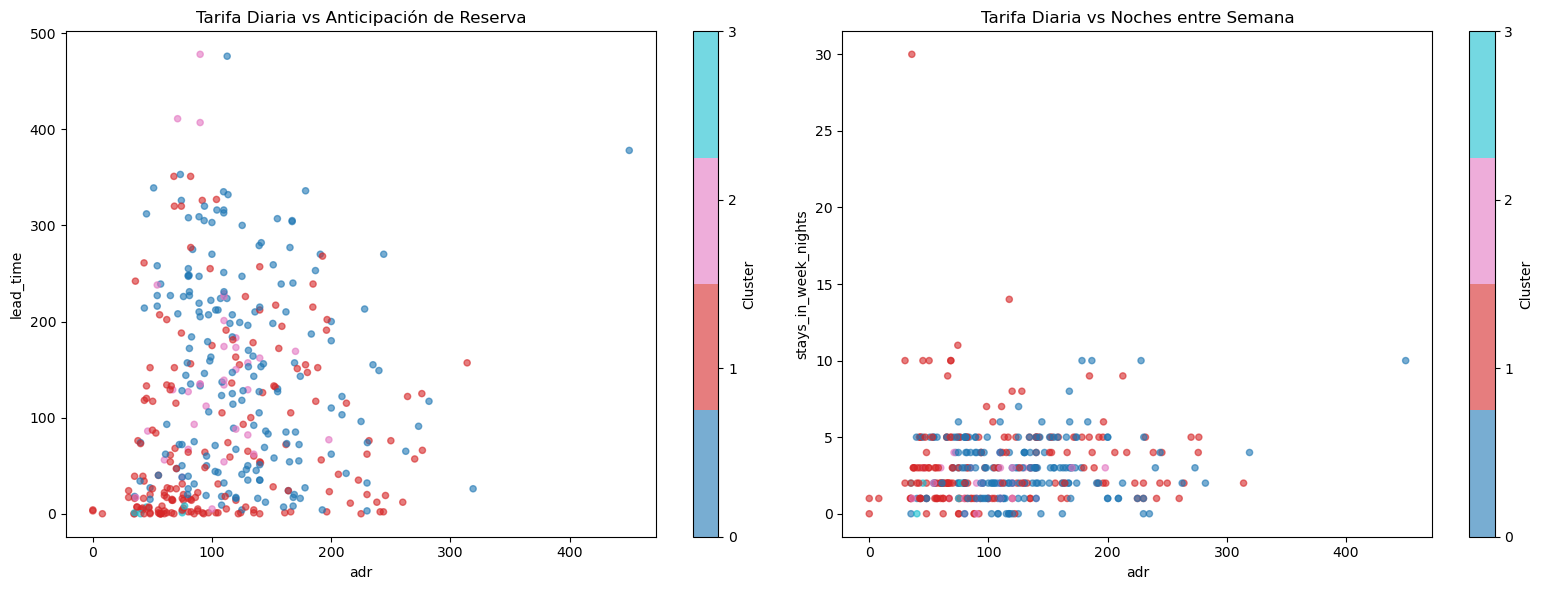

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
km.plot_dispersion('adr', 'lead_time', titulo='Tarifa Diaria vs Anticipación de Reserva')

plt.sca(axes[1])
km.plot_dispersion('adr', 'stays_in_week_nights', titulo='Tarifa Diaria vs Noches entre Semana')

plt.tight_layout()
plt.show()

### 6.4 Barras de centroides por cluster

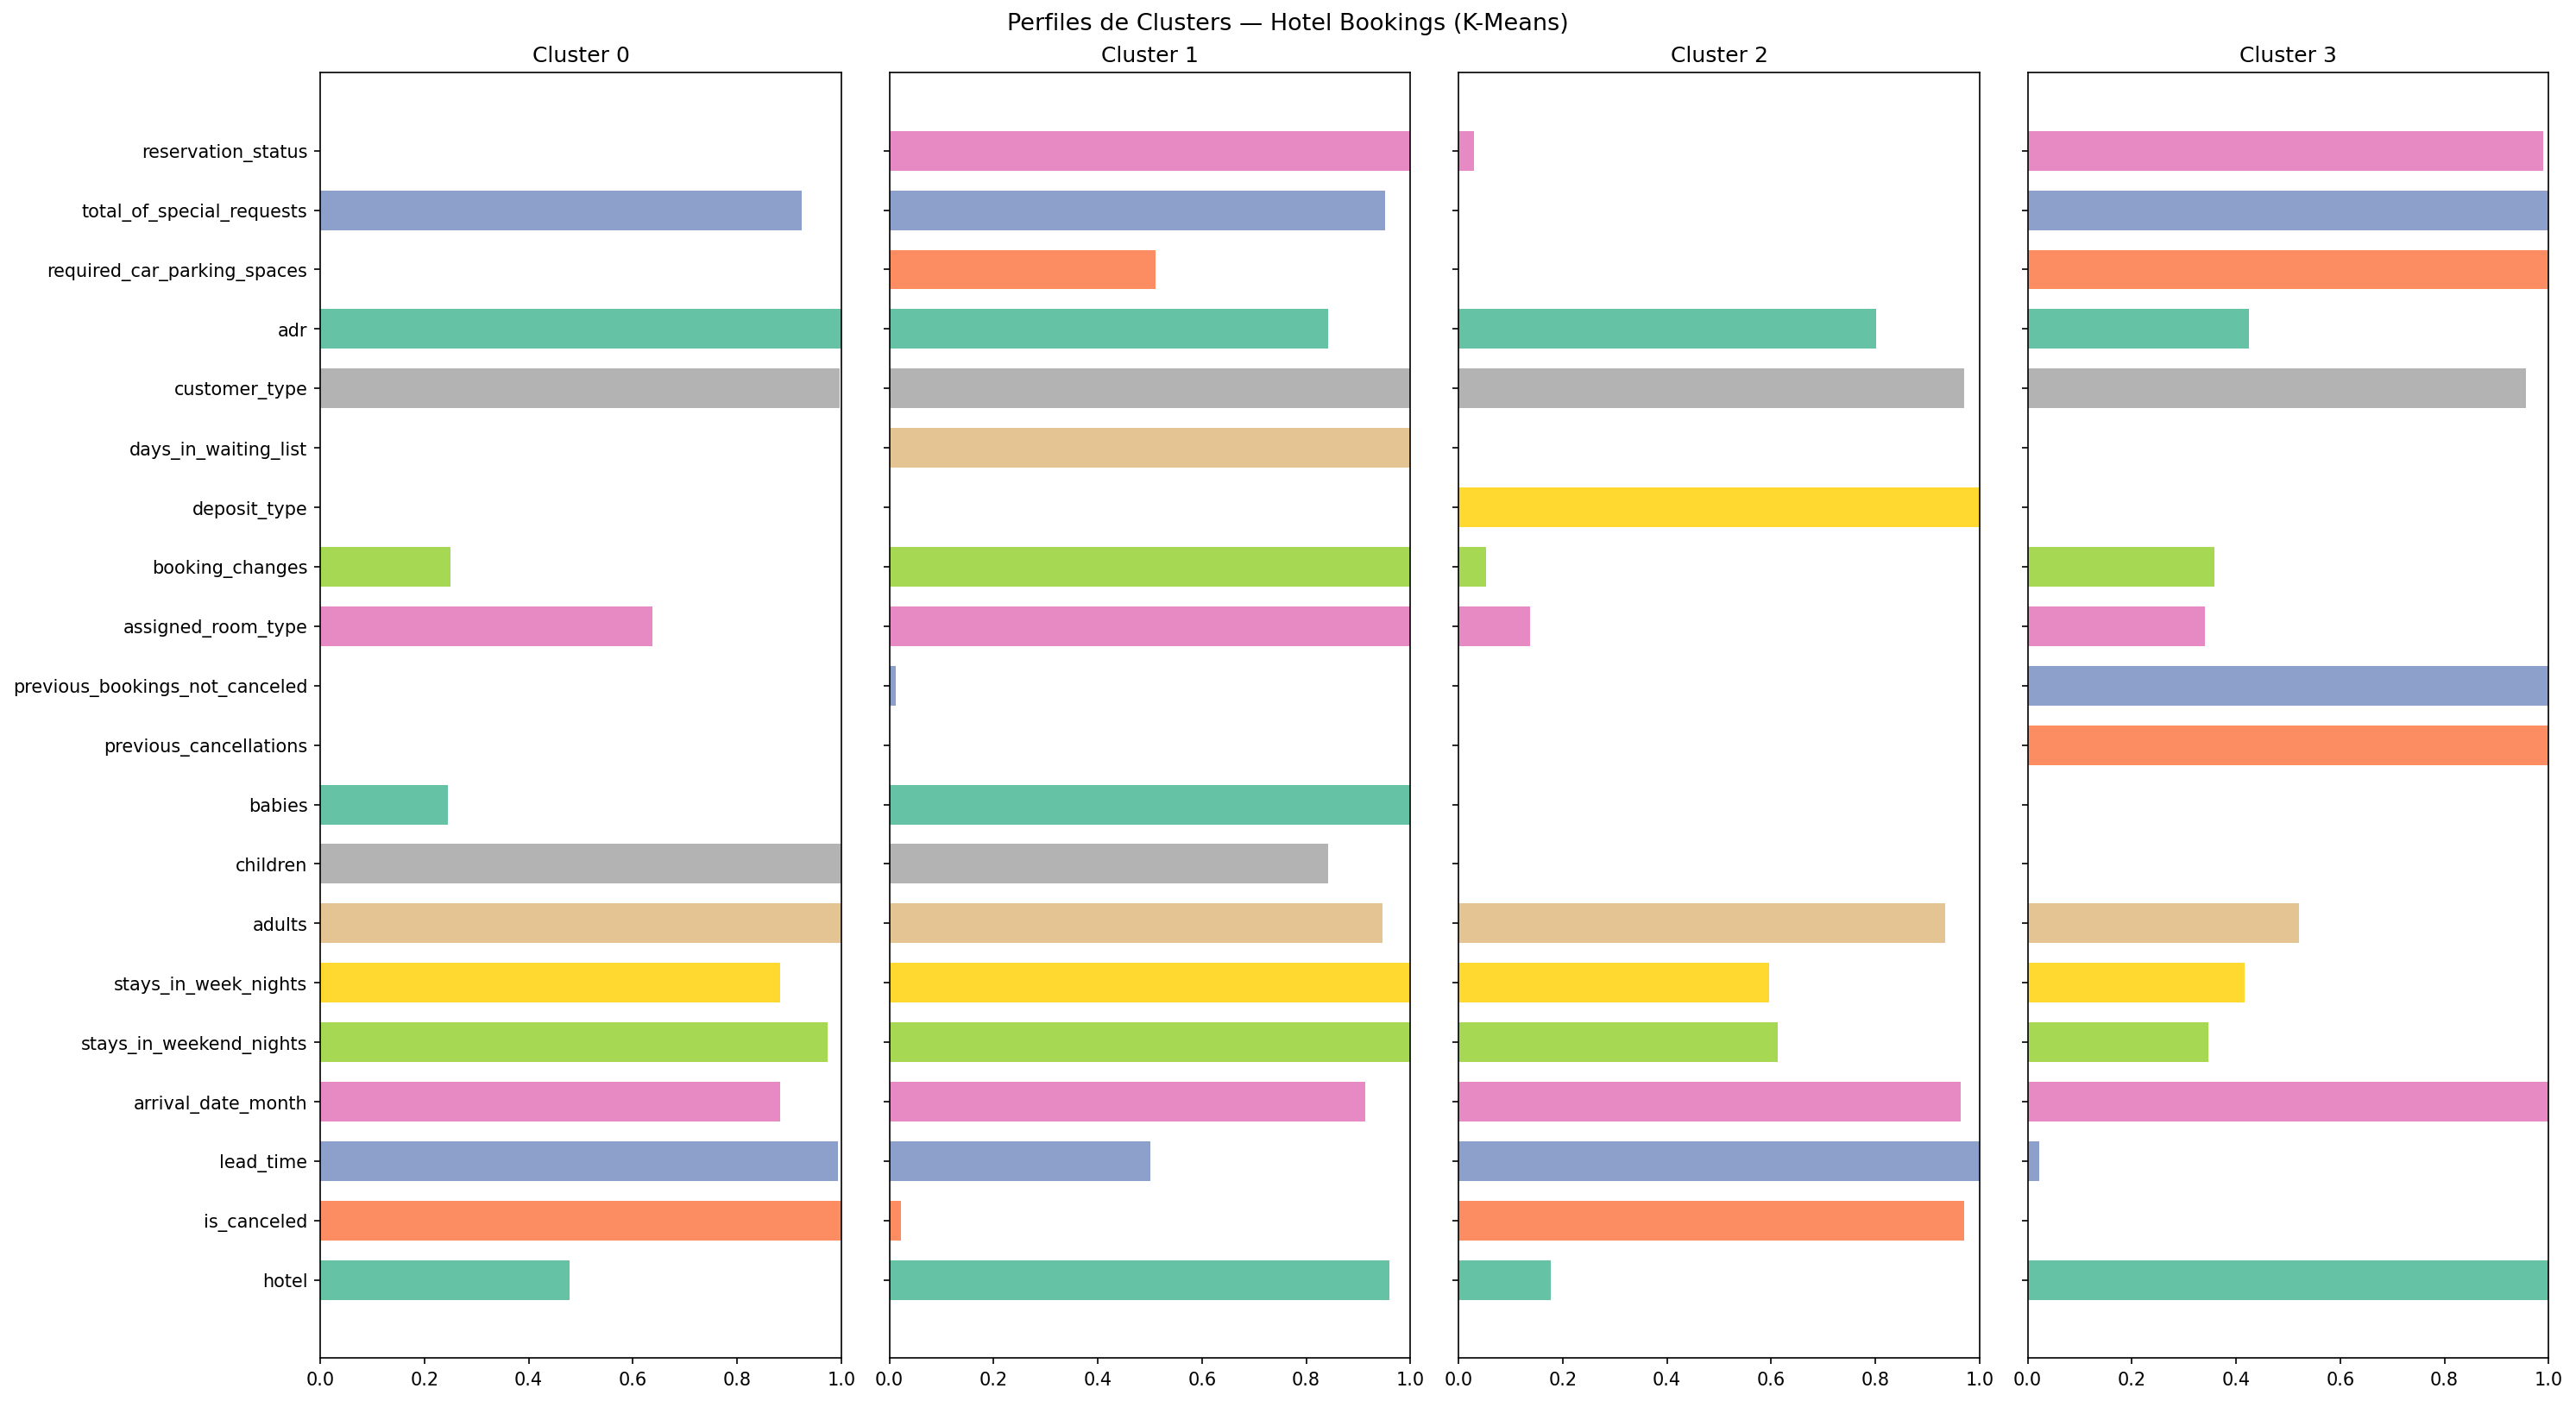

In [9]:
km.plot_barras(
    titulo='Perfiles de Clusters — Hotel Bookings (K-Means)',
    escala=True
)
plt.show()

### 6.5 Gráfico radar de clusters

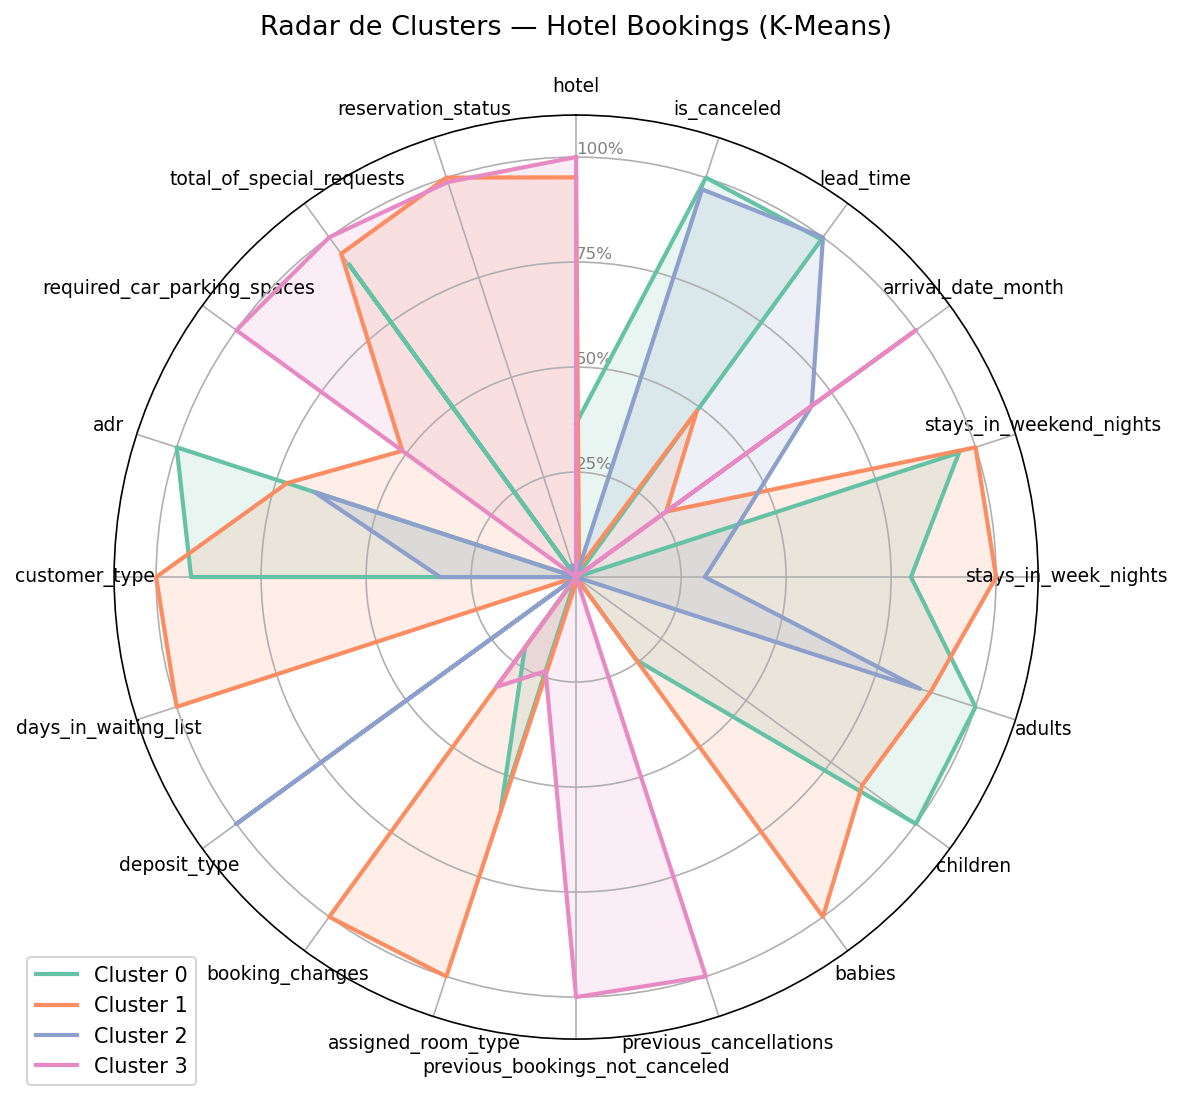

In [10]:
km.plot_radar(titulo='Radar de Clusters — Hotel Bookings (K-Means)')
plt.show()

## 7. Resumen estadístico por cluster

In [11]:
km.resumen.style.background_gradient(cmap='Blues', axis=0).format('{:.2f}')

,hotel,is_canceled,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
cluster,,,,,,,,,,,,,,,,,,,,
0,0.48,1.00,149.74,3.18,1.12,2.96,1.92,0.19,0.01,0.00,0.00,1.49,0.14,0.00,0.00,2.08,128.07,0.00,0.74,0.00
1,0.96,0.02,75.44,3.29,1.15,3.36,1.82,0.16,0.02,0.00,0.13,2.35,0.56,0.00,0.71,2.09,107.73,0.20,0.76,1.01
2,0.18,0.97,150.68,3.47,0.71,2.00,1.79,0.00,0.00,0.00,0.00,0.32,0.03,1.00,0.00,2.03,102.71,0.00,0.00,0.03
3,1.00,0.00,3.40,3.60,0.40,1.40,1.00,0.00,0.00,1.00,10.00,0.80,0.20,0.00,0.00,2.00,54.40,0.40,0.80,1.00


## 8. Conclusiones

- El **método del codo** y el **Silhouette** permiten elegir `k` de forma objetiva.
- El **mapa de calor** revela el perfil de cada cluster (e.g. reservas de lujo, cancelaciones frecuentes, etc.).
- K-Means es **no determinista**: distintas semillas pueden producir resultados diferentes. El parámetro `random_state=42` garantiza reproducibilidad.
- K-Means asume clusters **esféricos y de tamaño similar**. Si los clusters son irregulares, considera HAC con enlace completo o average.